<a href="https://colab.research.google.com/github/dayanamichellgomezmartinez-ux/Notebooks_Agro_2026_1/blob/main/Ejercicio_M%C3%A9todos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

           EJERCICIO 1: f(x)
  i         x_i           f(x_i)          f'(x_i)           ER%      
----------------------------------------------------------------------
  0     2.00000000    -1.51942590e+01  -23.07646572          —       
  1     1.34156906    -4.90433093e+00   -9.93043879       49.07916861
  2     0.84770056    -1.31705572e+00   -5.06279862       58.25978270
  3     0.58755675    -2.25061483e-01   -3.41127437       44.27552078
  4     0.52158097    -1.16691690e-02   -3.06164221       12.64919211
  5     0.51776956    -3.71031043e-05   -3.04218584        0.73612062
  6     0.51775736    -3.78890919e-10   -3.04212371        0.00235558
  7     0.51775736    1.11022302e-16    -3.04212371        0.00000002

Raíz Ejercicio 1: x = 5.177573636824583e-01 (f(x) = 1.110223024625157e-16)


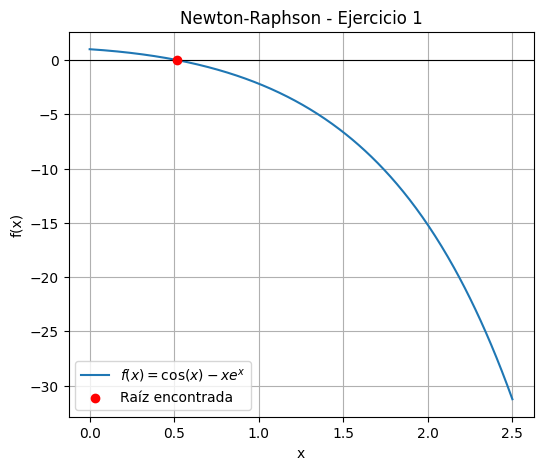


      EJERCICIO 2: Van der Waals (v)
  i         x_i           f(x_i)          f'(x_i)           ER%      
----------------------------------------------------------------------
  0     0.01552947    6.40155979e+01  14469.10378919         —       
  1     0.01110518    7.84947553e+00  10384.96847267      39.83993405
  2     0.01034933    4.05947035e-01   9283.65785048       7.30336914
  3     0.01030560    1.50315101e-03   9214.80753640       0.42430375
  4     0.01030544    2.10392841e-08   9214.54957953       0.00158289
  5     0.01030544    5.68434189e-14   9214.54957592       0.00000002

Raíz Ejercicio 2: v = 1.030543910303581e-02 (f(v) = 5.684341886080801e-14)


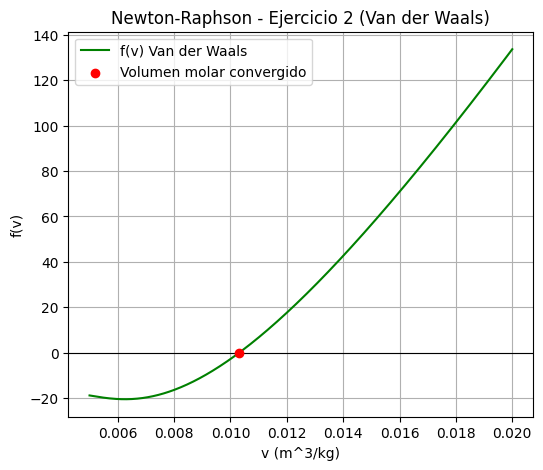

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def newton_raphson(f, df, x0, tolerancia_error):
    encabezado = '{:^5s} {:^15s} {:^15s} {:^15s} {:^15s}'.format('i', 'x_i', 'f(x_i)', "f'(x_i)", 'ER%')
    print(encabezado)
    print("-" * 70)

    i = 0
    x_actual = x0
    x_anterior = None
    finalizado = False

    while not finalizado:
        f0 = f(x_actual)
        df0 = df(x_actual)

        # Calcular el error relativo si no es la primera iteración
        if x_anterior is None:
            error_str = '—'.center(15)
            error_relativo = float('inf') # Se asigna infinito para evitar que se detenga en la iteración 0
        else:
            error_relativo = abs((x_actual - x_anterior) / x_actual) * 100.0
            error_str = f'{error_relativo:15.8f}'

        print('{:^5d} {:^15.8f} {:^15.8e} {:^15.8f} {:>15s}'.format(
            i, x_actual, f0, df0, error_str))

        # Criterio de parada: evaluar el Error Relativo Porcentual
        if x_anterior is not None and error_relativo < tolerancia_error:
            finalizado = True
        else:
            if df0 == 0:
                print("La derivada es cero, no hay solución.")
                return None
            x_anterior = x_actual
            x_actual = x_anterior - f0 / df0
            i += 1

    return x_actual

# ==========================================
# EJERCICIO 1: f(x) = cos(x) - x*exp(x)
# ==========================================
def f1(x):
    return np.cos(x) - x * np.exp(x)

def df1(x):
    return -np.sin(x) - np.exp(x) * (1 + x)

# ==========================================
# EJERCICIO 2: Van der Waals (Vapor de Agua)
# ==========================================
R = 0.4615
P = 20000.0
T = 673.0
Tcr = 647.1
Pcr = 22060.0

# Constantes a y b de Van der Waals
a = (27 * (R**2) * (Tcr**2)) / (64 * Pcr)
b = (R * Tcr) / (8 * Pcr)

def f2(v):
    return (P + a / (v**2)) * (v - b) - R * T

def df2(v):
    return P - a / (v**2) + (2 * a * b) / (v**3)

# ==========================================
# EJECUCIÓN PRINCIPAL
# ==========================================
def ejecucion_principal():
    limite_tolerancia_porcentual = 1e-4

    print("==========================================")
    print("           EJERCICIO 1: f(x)")
    print("==========================================")
    val_semilla_1 = 2.0
    raiz1 = newton_raphson(f1, df1, val_semilla_1, limite_tolerancia_porcentual)

    if raiz1 is not None:
        print(f"\nRaíz Ejercicio 1: x = {raiz1:.15e} (f(x) = {f1(raiz1):.15e})")
        X = np.linspace(0, 2.5, 400)
        Y = f1(X)
        plt.figure(figsize=(6, 5))
        plt.plot(X, Y, label=r'$f(x) = \cos(x) - x e^x$')
        plt.axhline(0, color='k', linewidth=0.8)
        plt.scatter([raiz1], [f1(raiz1)], color='red', label='Raíz encontrada', zorder=5)
        plt.title('Newton-Raphson - Ejercicio 1')
        plt.xlabel('x')
        plt.ylabel('f(x)')
        plt.legend()
        plt.grid(True)
        plt.show()

    print("\n==========================================")
    print("      EJERCICIO 2: Van der Waals (v)")
    print("==========================================")
    val_semilla_2 = R * T / P  # v0 = RT/P
    raiz2 = newton_raphson(f2, df2, val_semilla_2, limite_tolerancia_porcentual)

    if raiz2 is not None:
        print(f"\nRaíz Ejercicio 2: v = {raiz2:.15e} (f(v) = {f2(raiz2):.15e})")
        V = np.linspace(0.005, 0.02, 400)
        Y2 = f2(V)
        plt.figure(figsize=(6, 5))
        plt.plot(V, Y2, label='f(v) Van der Waals', color='green')
        plt.axhline(0, color='k', linewidth=0.8)
        plt.scatter([raiz2], [f2(raiz2)], color='red', label='Volumen molar convergido', zorder=5)
        plt.title('Newton-Raphson - Ejercicio 2 (Van der Waals)')
        plt.xlabel('v (m^3/kg)')
        plt.ylabel('f(v)')
        plt.legend()
        plt.grid(True)
        plt.show()

if __name__ == "__main__":
    ejecucion_principal()